In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import accuracy_score


import pickle

In [18]:
df = pd.read_csv("medical_1.csv")

df.head()

,fever,cough,headache,fatigue,chest_pain,breathing_problem,sore_throat,body_pain,nausea,disease
0,1,1,1,1,0,0,1,1,0,Flu
1,0,1,0,0,0,0,1,0,0,Cold
2,1,1,1,1,1,1,0,1,0,COVID
3,0,0,1,1,0,0,0,1,1,Migraine
4,1,0,1,1,0,0,0,1,1,Dengue


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   fever              120 non-null    int64 
 1   cough              120 non-null    int64 
 2   headache           120 non-null    int64 
 3   fatigue            120 non-null    int64 
 4   chest_pain         120 non-null    int64 
 5   breathing_problem  120 non-null    int64 
 6   sore_throat        120 non-null    int64 
 7   body_pain          120 non-null    int64 
 8   nausea             120 non-null    int64 
 9   disease            120 non-null    object
dtypes: int64(9), object(1)
memory usage: 9.5+ KB


In [20]:
df.describe()

,fever,cough,headache,fatigue,chest_pain,breathing_problem,sore_throat,body_pain,nausea
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.00000,120.000000,120.00000
mean,0.600000,0.600000,0.700000,0.775000,0.300000,0.300000,0.45000,0.650000,0.45000
std,0.491952,0.491952,0.460179,0.419333,0.460179,0.460179,0.49958,0.478969,0.49958
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.00000
50%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.00000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000


In [21]:
df.isnull()

,fever,cough,headache,fatigue,chest_pain,breathing_problem,sore_throat,body_pain,nausea,disease
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
115,False,False,False,False,False,False,False,False,False,False
116,False,False,False,False,False,False,False,False,False,False
117,False,False,False,False,False,False,False,False,False,False
118,False,False,False,False,False,False,False,False,False,False


In [22]:
X = df.drop("disease", axis=1)

y = df["disease"]

In [23]:
X

,fever,cough,headache,fatigue,chest_pain,breathing_problem,sore_throat,body_pain,nausea
0,1,1,1,1,0,0,1,1,0
1,0,1,0,0,0,0,1,0,0
2,1,1,1,1,1,1,0,1,0
3,0,0,1,1,0,0,0,1,1
4,1,0,1,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...
115,1,1,0,1,1,1,0,1,0
116,0,0,1,0,0,0,0,0,1
117,1,1,1,1,1,1,1,1,1
118,0,1,0,1,0,0,1,0,0


In [24]:
y

0                   Flu
1                  Cold
2                 COVID
3              Migraine
4                Dengue
             ...       
115           Pneumonia
116      Food Poisoning
117        Tuberculosis
118    Throat Infection
119             Typhoid
Name: disease, Length: 120, dtype: object

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("disease", axis=1)
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.8333333333333334


In [27]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.75


In [28]:
pickle.dump(rf, open("model.pkl", "wb"))

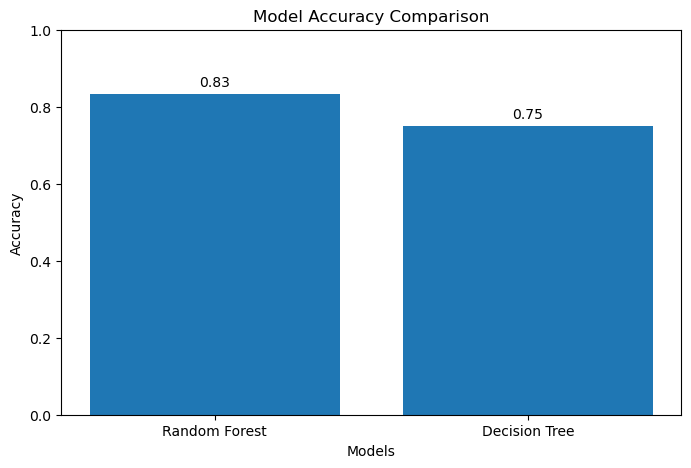

In [30]:
import matplotlib.pyplot as plt

# Model names         
models = ["Random Forest", "Decision Tree"]

# Accuracy values
accuracy = [rf_acc, dt_acc]

# Create graph
plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylim(0,1)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

# Show accuracy values on bars
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.02, str(round(v,2)), ha='center')

plt.show()